In [14]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
from datasets import load_dataset
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from umap import UMAP

In [5]:
dataset = load_dataset('maartengr/arxiv_nlp')['train']
abstracts = dataset['Abstracts']
titles = dataset['Titles']

In [6]:
embedding_mod = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_mod.encode(abstracts, show_progress_bar=True)

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [7]:
embeddings.shape

(44949, 384)

In [9]:
umap_mod = UMAP(
    n_components=5, min_dist=0., metric='cosine', random_state=123)
reduced_embeddings = umap_mod.fit_transform(embeddings)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
hdbscan_mod = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_mod.labels_
len(set(clusters))

165

### Inspecting Clusters

In [17]:
cluster = 1
for i in np.where(clusters == cluster)[0][:3]:
    print(abstracts[i][:300])
    print()

  A computer model of "a sense of humour" suggested previously
[arXiv:0711.2058,0711.2061], relating the humorous effect with a specific
malfunction in information processing, is given in somewhat different
exposition. Psychological aspects of humour are elaborated more thoroughly. The
mechanism of 

  Computer model of a "sense of humour" suggested previously [arXiv:0711.2058,
0711.2061, 0711.2270] is raised to the level of a realistic algorithm.


  The New Yorker publishes a weekly captionless cartoon. More than 5,000
readers submit captions for it. The editors select three of them and ask the
readers to pick the funniest one. We describe an experiment that compares a
dozen automatic methods for selecting the funniest caption. We show that
n



In [18]:
reduced_embeddings = UMAP(
    n_components=2, min_dist=0., metric='cosine', random_state=123
).fit_transform(embeddings)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])
df['title'] = titles
df['cluster'] = [str(c) for c in clusters]

In [20]:
to_plot = df.loc[df.cluster != '-1', :]
outliers = df.loc[df.cluster == '-1', :]

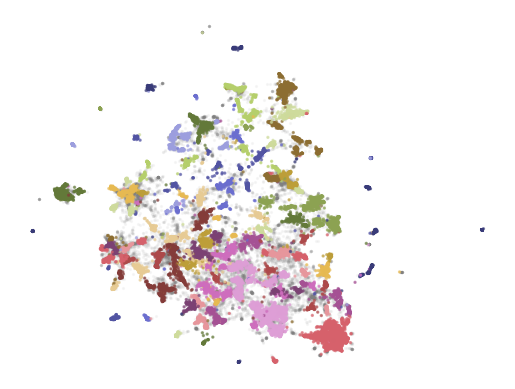

In [22]:
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2, c='grey')
plt.scatter(
    to_plot.x,
    to_plot.y, 
    c=to_plot.cluster.astype(int),
    alpha=0.6,
    s=2,
    cmap='tab20b')
plt.axis('off');

## From Text Clustering to Topic Modeling